In [15]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
pairs = pd.read_csv(r"/content/drive/MyDrive/immverse.ai/query_pairs.csv")

pairs.head()

,query,document,label
0,What does this verse say?,Verse ID: 137\n\nSanskrit:\nप्रकृतेः क्रियमाणा...,1
1,Explain verse 137,Verse ID: 137\n\nSanskrit:\nप्रकृतेः क्रियमाणा...,1
2,Explain verse 326,Verse ID: 326\n\nSanskrit:\nमया ततमिदं सर्वं ज...,1
3,What does this verse say?,Verse ID: 547\n\nSanskrit:\nअनेकचित्तविभ्रान्त...,1
4,एतान्यपि तु कर्माणि सङ्गं त्यक्त्वा फलानि च ।क...,Verse ID: 587\n\nSanskrit:\nएतान्यपि तु कर्माण...,1


In [3]:
MODEL_PATH = "/content/drive/MyDrive/immverse.ai/models"

model = SentenceTransformer(MODEL_PATH)

print("Model Loaded")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model Loaded


In [4]:
queries = pairs["query"].tolist()

documents = pairs["document"].tolist()

len(queries), len(documents)

(3942, 3942)

In [5]:
query_embeddings = model.encode(
    queries,
    convert_to_numpy=True,
    show_progress_bar=True
)

document_embeddings = model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/124 [00:00<?, ?it/s]

Batches:   0%|          | 0/124 [00:00<?, ?it/s]

Cosine Similarity Matrix

In [6]:
similarity_matrix = cosine_similarity(
    query_embeddings,
    document_embeddings
)

similarity_matrix.shape

(3942, 3942)

Recall@K

In [7]:
def recall_at_k(similarity_matrix, k):

    correct = 0

    for i in range(len(similarity_matrix)):

        top_k = np.argsort(similarity_matrix[i])[::-1][:k]

        if i in top_k:

            correct += 1

    return correct / len(similarity_matrix)

MRR

In [8]:
def mean_reciprocal_rank(similarity_matrix):

    rr = []

    for i in range(len(similarity_matrix)):

        ranking = np.argsort(similarity_matrix[i])[::-1]

        rank = np.where(ranking == i)[0][0] + 1

        rr.append(1 / rank)

    return np.mean(rr)

nDCG

In [9]:
def ndcg_at_k(similarity_matrix, k=10):

    scores = []

    for i in range(len(similarity_matrix)):

        ranking = np.argsort(similarity_matrix[i])[::-1][:k]

        if i in ranking:

            rank = np.where(ranking == i)[0][0]

            dcg = 1 / np.log2(rank + 2)

        else:

            dcg = 0

        idcg = 1

        scores.append(dcg / idcg)

    return np.mean(scores)

Evaluate

In [10]:
recall1 = recall_at_k(similarity_matrix, 1)

recall5 = recall_at_k(similarity_matrix, 5)

recall10 = recall_at_k(similarity_matrix, 10)

mrr = mean_reciprocal_rank(similarity_matrix)

ndcg = ndcg_at_k(similarity_matrix, 10)

In [11]:
results = pd.DataFrame({

    "Metric":[
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR",
        "nDCG@10"
    ],

    "Score":[
        recall1,
        recall5,
        recall10,
        mrr,
        ndcg
    ]

})

results

,Metric,Score
0,Recall@1,0.129376
1,Recall@5,0.686707
2,Recall@10,0.830797
3,MRR,0.334350
4,nDCG@10,0.453606


In [13]:
results.to_csv(
    "/content/drive/MyDrive/immverse.ai/evaluation_results.csv",
    index=False
)

print("Results Saved")

Results Saved


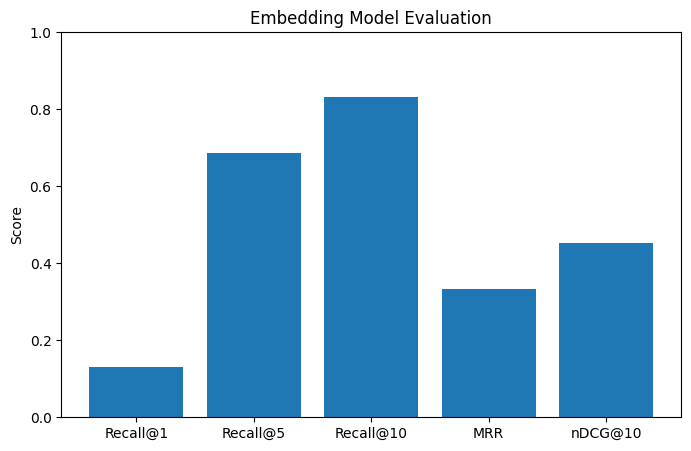

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Metric"],
    results["Score"]
)

plt.ylim(0,1)

plt.title("Embedding Model Evaluation")

plt.ylabel("Score")

plt.show()